# Learning:

**ROC Curver - Reciever operating characteristics:**

* A plot which illustrated the performance of a binary classifier model.
* Is the plot of the true positive rate (TPR) against the false positive rate (FPR) at each threshold setting.

**Binary classification - The task of putting things into one or two categories**

* Easiest form of classification.

# Pre-Reqs:

In [1]:
#PIPS:
pip install optuna catboost

SyntaxError: invalid syntax (2778129411.py, line 2)

In [3]:
#Packages:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score, classification_report
from scipy.stats import uniform, randint, stats
from catboost import CatBoostClassifier
from itertools import product

#Ignore output warnings
warnings.filterwarnings("ignore")

# Data:

In [4]:
#Import and Clean
TrainDataset = pd.read_csv('/content/train.csv')
TestDataset = pd.read_csv('/content/test.csv')

missingTest = TestDataset.isna().sum()
missingTrain = TrainDataset.isna().sum()

if missingTest.sum() > 0 or missingTrain.sum() > 0:
  print("missing values!")
  if missingTest.sum() > 0:
    print("\n")
    TestDataset.isna().sum()
    print("\n")
  if missingTrain.sum() > 0:
    print("\n")
    TrainDataset.isna.sum()
    print("\n")
else:
  print("No missing values!")
  print("\n")

#Encoding values

#Values needing to be changed to numerical
print("columns that need to be changed to numeric in Datasets:\n")
trainNonNumeric = TrainDataset.select_dtypes(exclude=["number"]).columns
testNonNumeric = TestDataset.select_dtypes(exclude=["number"]).columns

if len(trainNonNumeric) > 0:
    print("############In Train############")
    print(trainNonNumeric)
    print("\n")
else:
    print("No values in Train need to be converted")
    print("\n")
if len(testNonNumeric) > 0:
    print("############In Test############")
    print(testNonNumeric)
    print("\n")
else:
    print("No values in Test need to be converted")
    print("\n")

######Encoding Train
Target = "Churn"

# Encode target separately if it exists
if Target in TrainDataset.columns:
    le_target = LabelEncoder()
    TrainDataset[Target] = le_target.fit_transform(TrainDataset[Target].astype(str))

# Encode non-numeric features
trainNonNumeric = TrainDataset.select_dtypes(exclude=["number"]).columns.drop(Target, errors="ignore")

for col in trainNonNumeric:
    if col in TestDataset.columns:
        le = LabelEncoder()
        TrainDataset[col] = TrainDataset[col].astype(str)
        fitTest = pd.concat([TrainDataset[col], TestDataset[col]], axis=0).unique()
        le.fit(fitTest)
        TrainDataset[col] = le.transform(TrainDataset[col])

######Encoding Test
testNonNumeric = TestDataset.select_dtypes(exclude=["number"]).columns.drop(Target, errors="ignore")

for col in trainNonNumeric:
    if col in TestDataset.columns:

        TestDataset[col] = TestDataset[col].astype(str)
        fitTest = pd.concat([TestDataset[col], TestDataset[col]], axis=0).unique()
        le.fit(fitTest)
        TestDataset[col] = le.transform(TestDataset[col])

# Check if fully numeric
Train_Numerical = TrainDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()
print(f"Train Dataset Numerical? {Train_Numerical}")
print("\n")
Test_Numerical = TestDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()
print(f"Test Dataset Numerical? {Test_Numerical}")



No missing values!


columns that need to be changed to numeric in Datasets:

############In Train############
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


############In Test############
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


Train Dataset Numerical? True


Test Dataset Numerical? True


In [5]:
print(TestDataset.select_dtypes(include=["object"]).columns)

Index([], dtype='object')


# Data Analysis:

**Some EDA:**

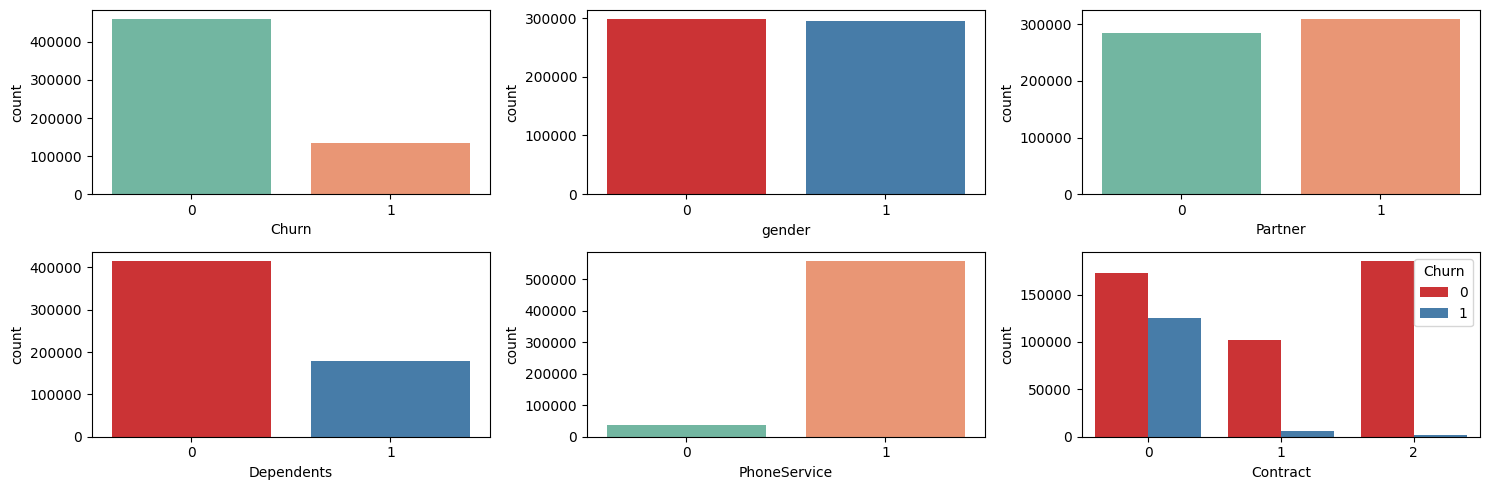

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15,5))
#Line 1:
sns.countplot(x="Churn", palette="Set2", data=TrainDataset, ax=ax[0,0])
sns.countplot(x="gender", palette="Set1", data=TrainDataset, ax=ax[0,1])
sns.countplot(x="Partner", palette="Set2", data=TrainDataset, ax=ax[0,2])
#Line 2:
sns.countplot(x="Dependents", palette="Set1", data=TrainDataset, ax=ax[1,0])
sns.countplot(x="PhoneService", palette="Set2", data=TrainDataset, ax=ax[1,1])
sns.countplot(x="Contract", hue="Churn", palette="Set1", data=TrainDataset, ax=ax[1,2])
#Plot:
plt.tight_layout()
plt.show()

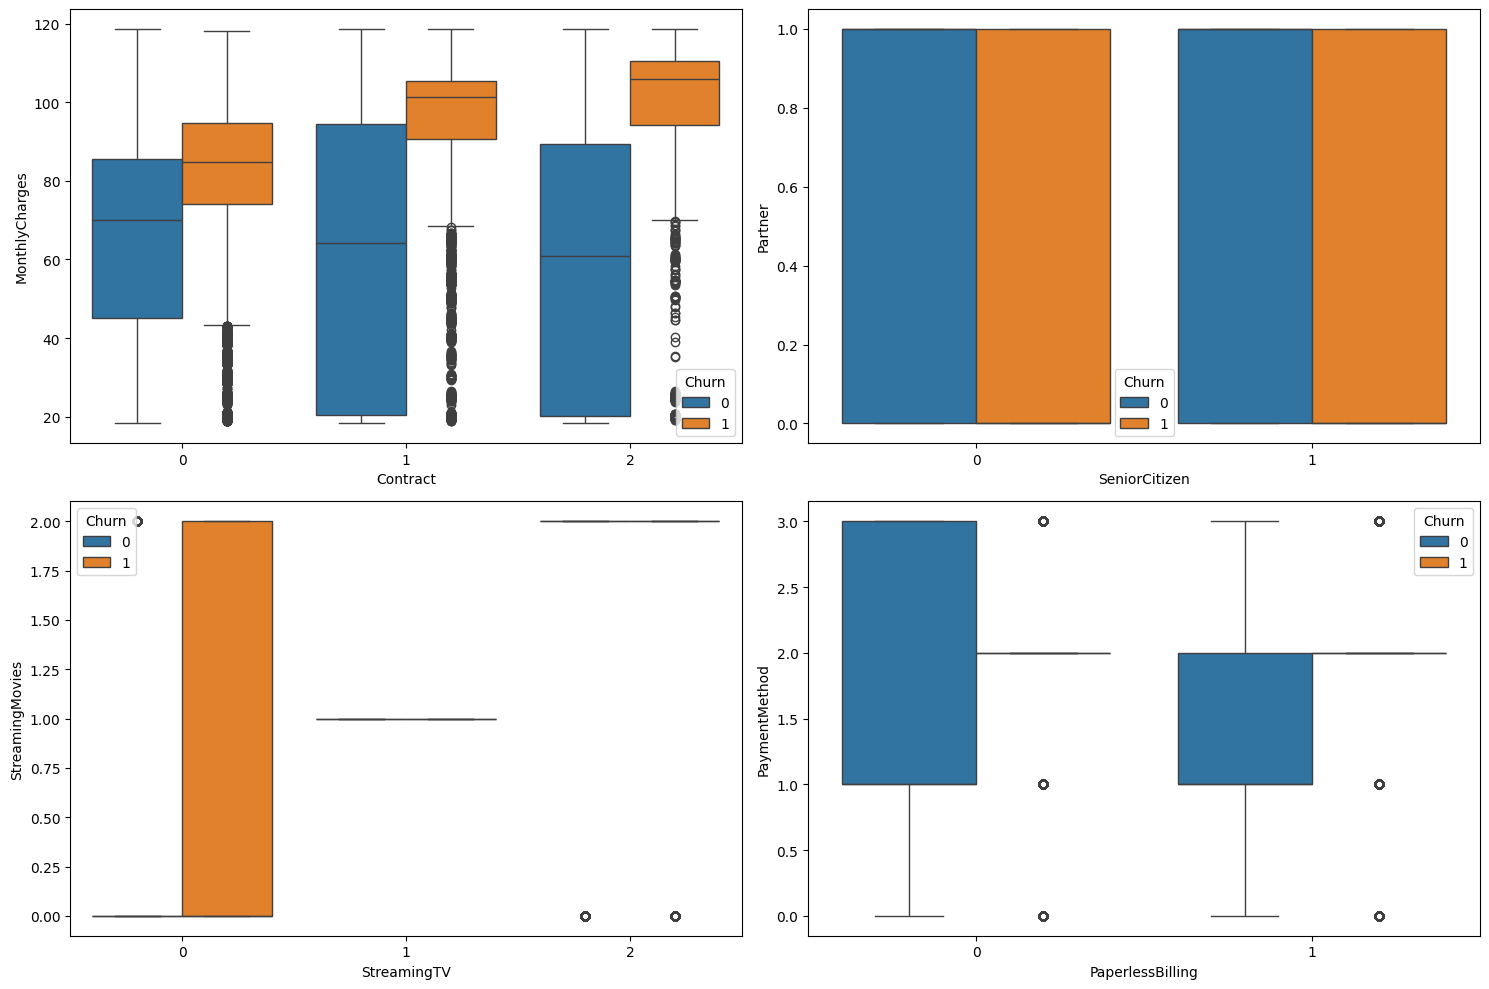

In [ ]:
#Feature Ineraction Analysis
fig, ax = plt.subplots(2, 2, figsize=(15,10))

#Line 1:
sns.boxplot(x="Contract", y="MonthlyCharges", hue="Churn", data=TrainDataset ,ax=ax[0,0])
sns.boxplot(x="SeniorCitizen", y="Partner", hue="Churn", data=TrainDataset ,ax=ax[0,1])
#Line 2:
sns.boxplot(x="StreamingTV", y="StreamingMovies", hue="Churn", data=TrainDataset ,ax=ax[1,0])
sns.boxplot(x="PaperlessBilling", y="PaymentMethod", hue="Churn", data=TrainDataset ,ax=ax[1,1])
#Plot:
plt.tight_layout()
plt.show()

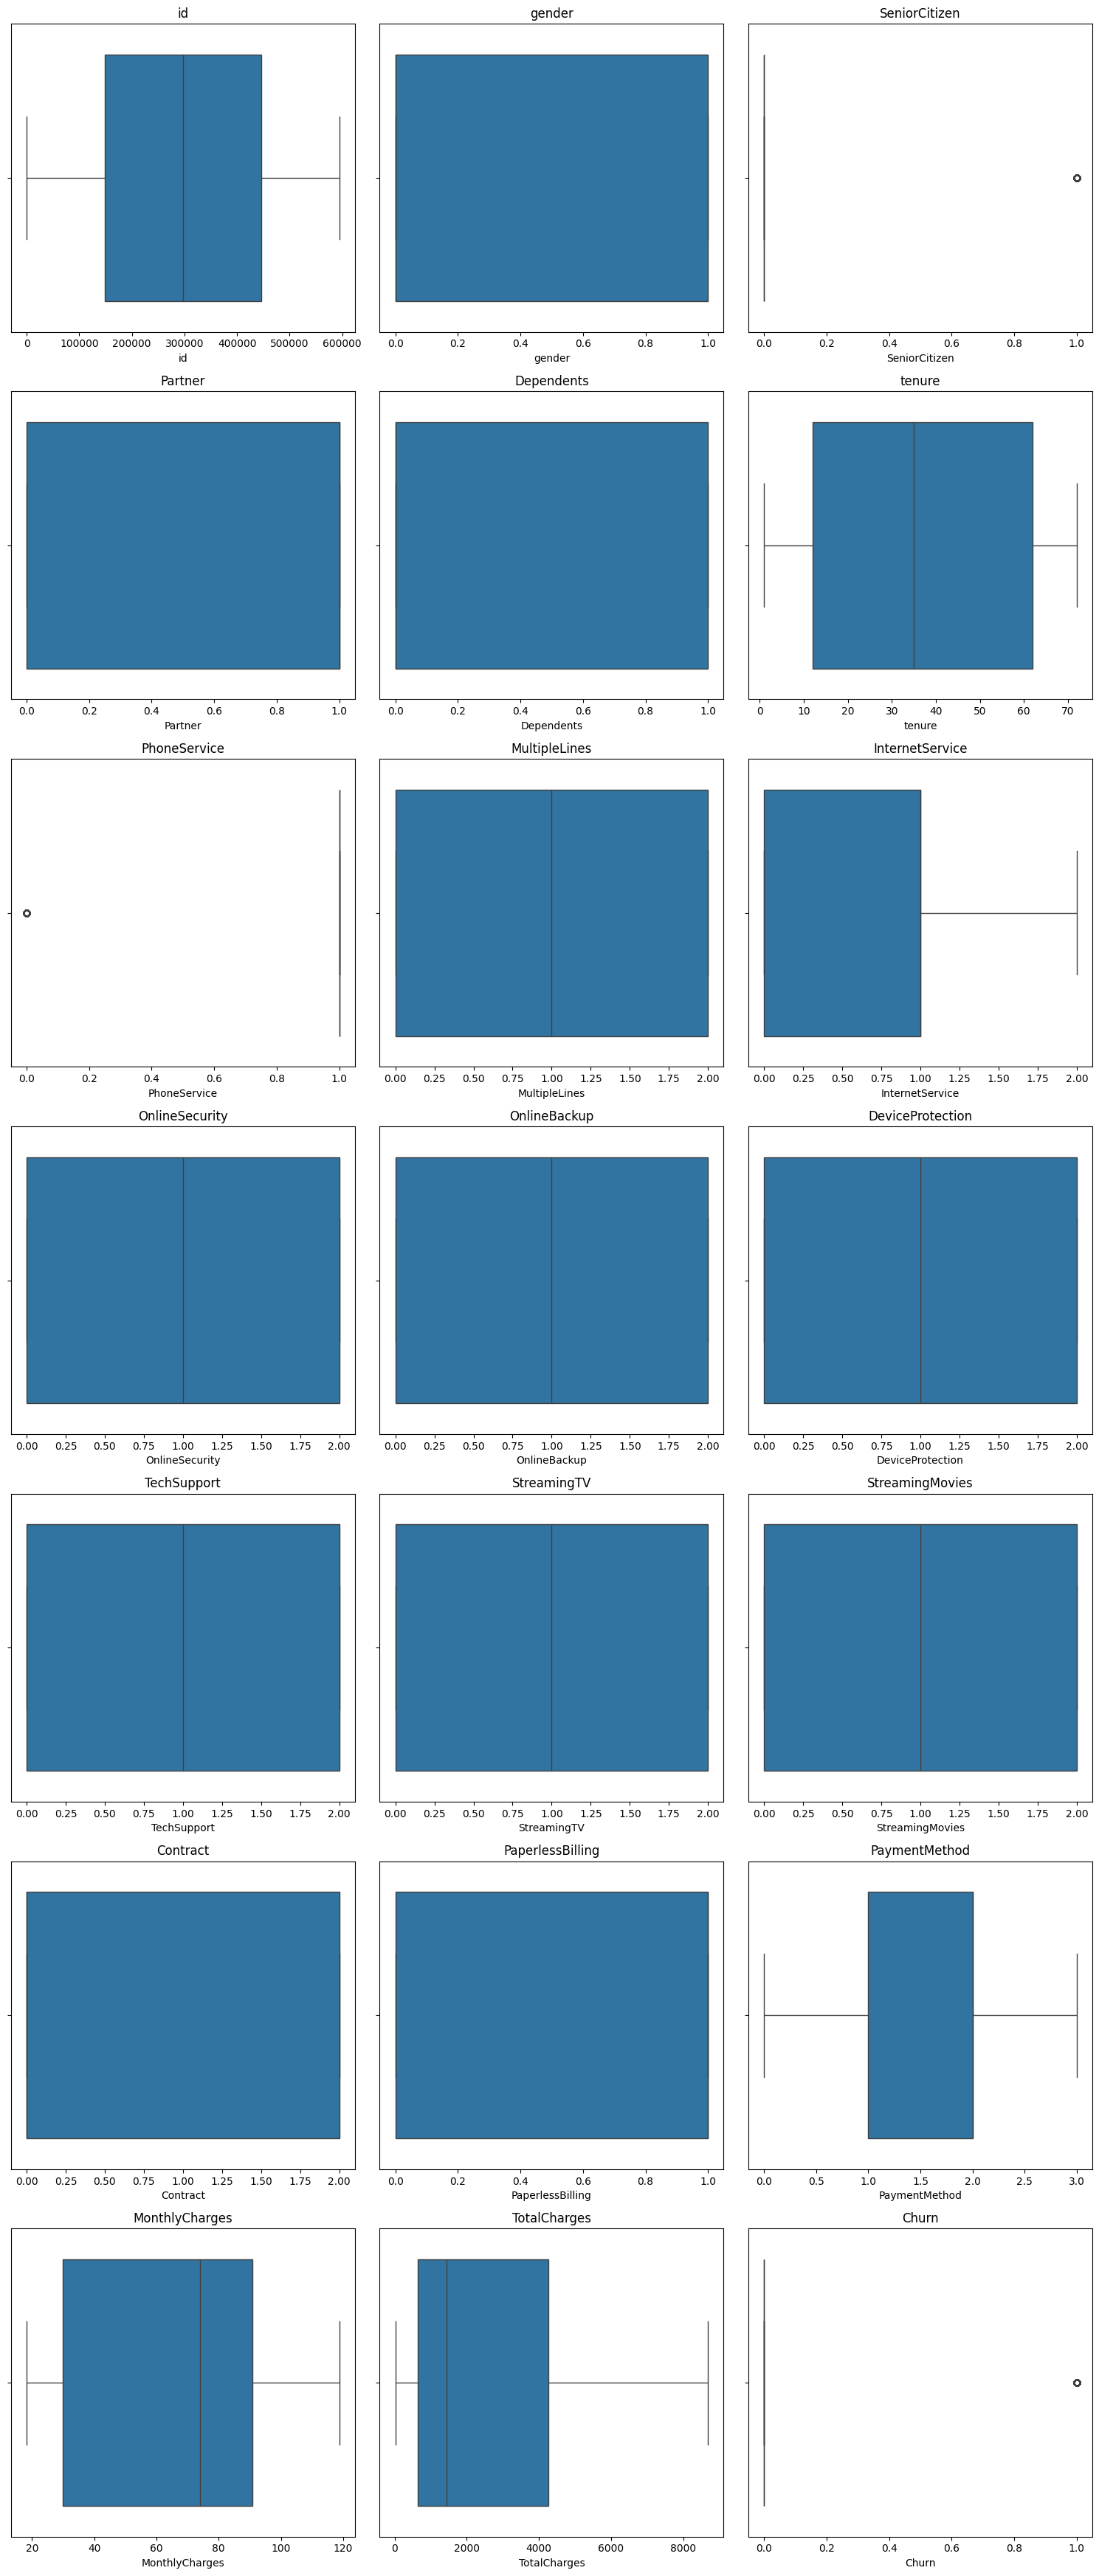

In [ ]:
#Outlier Detection
num_cols = TrainDataset.select_dtypes(include=["int64","float64"]).columns

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=TrainDataset[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty plots if columns not divisible by grid
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Model 1 - Logistic Regression:

* Logistic regression - A supervised ML algorithm used for binary classification

In [ ]:
Target = "Churn"
IDcol = "id"

y = TrainDataset[Target]
X = TrainDataset.drop([Target, IDcol], axis=1)
X_kaggle_test = TestDataset.drop([IDcol], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_kaggle_test_scaled = scaler.transform(X_kaggle_test)

model = LogisticRegression(
    C=1,
    penalty="l2",
    solver="lbfgs",
    class_weight="balanced",  # handles imbalanced target
    max_iter=3000,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring="roc_auc")

print(f"Cross-Validation ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f}\n")

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_valid_scaled)
y_prob = model.predict_proba(X_valid_scaled)[:,1]

roc_auc = roc_auc_score(y_valid, y_prob)
f1 = f1_score(y_valid, y_pred)

print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Validation F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, y_pred))

test_prob = model.predict_proba(X_kaggle_test_scaled)[:,1]

submission = pd.DataFrame({
    IDcol: TestDataset[IDcol],
    Target: test_prob  # probabilities for ROC-AUC
})

submission.to_csv("KaggleChurnModel1LR.csv", index=False)
print("\nSubmission saved as 'KaggleChurnModel1LR.csv'")

Cross-Validation ROC-AUC scores: [0.9047097  0.9055024  0.9051423  0.9061863  0.90307383]
Mean CV ROC-AUC: 0.9049

Validation ROC-AUC: 0.9060
Validation F1 Score: 0.6667

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.78      0.86    115095
           1       0.54      0.88      0.67     33454

    accuracy                           0.80    148549
   macro avg       0.75      0.83      0.76    148549
weighted avg       0.86      0.80      0.82    148549


Submission saved as 'KaggleChurnModel1LR.csv'


# Model 2 - XGB

In [ ]:
Target = "Churn"
IDcol = "id"

X = TrainDataset.drop([Target, IDcol], axis=1).copy()
X_test = TestDataset.drop([IDcol], axis=1).copy()

# Contract × MonthlyCharges interaction
X["Contract_Charges"] = X["Contract"] * X["MonthlyCharges"]
X_test["Contract_Charges"] = X_test["Contract"] * X_test["MonthlyCharges"]

# Example engineered features
X['AvgMonthlyCharge'] = X['TotalCharges'] / (X['tenure'] + 1)
X_test['AvgMonthlyCharge'] = X_test['TotalCharges'] / (X_test['tenure'] + 1)

X['HasFamily'] = ((TrainDataset['Partner']==1) | (TrainDataset['Dependents']==1)).astype(int)
X_test['HasFamily'] = ((TestDataset['Partner']==1) | (TestDataset['Dependents']==1)).astype(int)

y = TrainDataset[Target]

scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1),
        "scale_pos_weight": scale_pos_weight
    }

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        use_label_encoder=False,
        random_state=42,
        **params
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = []
    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False,
            #early_stopping_rounds=50
        )

        preds = model.predict_proba(X_valid)[:,1]
        auc = roc_auc_score(y_valid, preds)
        scores.append(auc)

    return sum(scores) / len(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=75)

print("Best parameters:", study.best_params)
print("Best CV ROC-AUC:", study.best_value)

best_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    **study.best_params
)

best_model.fit(X, y)

y_test_prob = best_model.predict_proba(X_test)[:,1]

submission = pd.DataFrame({
    IDcol: TestDataset[IDcol],
    Target: y_test_prob  # use probabilities for better evaluation
})

submission.to_csv("KaggleChurnModel2XGB_Enhanced.csv", index=False)
print("Submission saved as 'KaggleChurnModel2XGB_Enhanced.csv'")

# Model 3 - Ensemble XGB vs Catboost:

In [ ]:
# Target and ID
Target = "Churn"
IDcol = "id"

# Features
y = TrainDataset[Target]
X = TrainDataset.drop([Target, IDcol], axis=1).copy()
X_test = TestDataset.drop([IDcol], axis=1).copy()


if 'Contract' in X.columns and 'MonthlyCharges' in X.columns:
    X['Contract_MonthlyCharges'] = X['Contract'] * X['MonthlyCharges']
    X_test['Contract_MonthlyCharges'] = X_test['Contract'] * X_test['MonthlyCharges']

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1)
    }

    oof = np.zeros(len(X))
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42,
            use_label_encoder=False,
            **params
        )

        model.fit(X_train, y_train)
        oof[valid_idx] = model.predict_proba(X_valid)[:,1]

    return roc_auc_score(y, oof)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Optuna best params:", study.best_params)
print("Optuna best CV ROC-AUC:", study.best_value)

# Train fresh XGB with best params
fresh_xgb = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    use_label_encoder=False,
    **study.best_params
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def get_oof_preds(model, X, y, X_test):
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        oof[valid_idx] = model.predict_proba(X_valid)[:,1]
        test_pred += model.predict_proba(X_test)[:,1] / cv.n_splits
    return oof, test_pred

# Fresh XGB
oof_xgb_new, test_xgb_new = get_oof_preds(fresh_xgb, X, y, X_test)

# Your tuned XGB (if available)
# Example:
# oof_xgb_old, test_xgb_old = get_oof_preds(your_tuned_xgb, X, y, X_test)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight="balanced", max_iter=3000)
oof_lr, test_lr = get_oof_preds(lr, X, y, X_test)

# CatBoost
cat = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, eval_metric='AUC', random_seed=42, verbose=0)
oof_cat, test_cat = get_oof_preds(cat, X, y, X_test)

# Combine all models (add your tuned XGB if desired)
X_meta = np.column_stack((oof_xgb_new, oof_lr, oof_cat))
X_test_meta = np.column_stack((test_xgb_new, test_lr, test_cat))

def hill_climb_ensemble(oof_preds, y_true, n_iter=500):
    best_score = 0
    best_weights = None
    n_models = oof_preds.shape[1]

    for _ in range(n_iter):
        weights = np.random.rand(n_models)
        weights /= weights.sum()
        ensemble_pred = np.dot(oof_preds, weights)
        score = roc_auc_score(y_true, ensemble_pred)
        if score > best_score:
            best_score = score
            best_weights = weights
    return best_weights, best_score

weights, hill_auc = hill_climb_ensemble(X_meta, y, n_iter=1000)
print("Best Hill Climbing weights:", weights)
print("Hill Climbing CV ROC-AUC:", hill_auc)

# Apply weights to test predictions
final_test_pred = np.dot(X_test_meta, weights)

submission = pd.DataFrame({
    IDcol: TestDataset[IDcol],
    Target: final_test_pred
})

submission.to_csv("Kaggle_Stacked_XGB_LR_CatBoost_HC.csv", index=False)
print("Submission saved with stacked Hill Climbing ensemble!")

[I 2026-03-27 10:08:35,838] A new study created in memory with name: no-name-7f7b2f2b-9229-425d-a772-e14a037119df
[I 2026-03-27 10:09:50,396] Trial 0 finished with value: 0.9146647752157823 and parameters: {'n_estimators': 288, 'max_depth': 5, 'learning_rate': 0.05253126960560643, 'subsample': 0.9973368027474795, 'colsample_bytree': 0.6917393151209047, 'gamma': 4.463493288641857, 'min_child_weight': 8, 'reg_alpha': 0.6323555547784488, 'reg_lambda': 0.9943092176270205}. Best is trial 0 with value: 0.9146647752157823.
[I 2026-03-27 10:11:06,111] Trial 1 finished with value: 0.915734043499021 and parameters: {'n_estimators': 327, 'max_depth': 7, 'learning_rate': 0.21760359552231212, 'subsample': 0.786356004044749, 'colsample_bytree': 0.6597267944335364, 'gamma': 1.4980062916121333, 'min_child_weight': 10, 'reg_alpha': 0.2500772555592248, 'reg_lambda': 0.9396941017176466}. Best is trial 1 with value: 0.915734043499021.
[I 2026-03-27 10:12:13,274] Trial 2 finished with value: 0.916046368109

Optuna best params: {'n_estimators': 360, 'max_depth': 4, 'learning_rate': 0.19643528971274077, 'subsample': 0.9560598578047845, 'colsample_bytree': 0.9415686394806081, 'gamma': 0.6430393416538368, 'min_child_weight': 4, 'reg_alpha': 0.3068497360918979, 'reg_lambda': 0.8005782748411122}
Optuna best CV ROC-AUC: 0.9163566097023794
Best Hill Climbing weights: [0.70929688 0.00315247 0.28755065]
Hill Climbing CV ROC-AUC: 0.916427596203759
Submission saved with stacked Hill Climbing ensemble!


# Model 4 - Singlular CatBoost:

In [ ]:
Target = "Churn"
IDcol = "id"

y = TrainDataset[Target]
X = TrainDataset.drop([Target, IDcol], axis=1).copy()
X_test = TestDataset.drop([IDcol], axis=1).copy()


# Add Contract × MonthlyCharges interaction

if 'Contract' in X.columns and 'MonthlyCharges' in X.columns:
    X['Contract_MonthlyCharges'] = X['Contract'] * X['MonthlyCharges']
    X_test['Contract_MonthlyCharges'] = X_test['Contract'] * X_test['MonthlyCharges']

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 0, 2),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'eval_metric': 'AUC',
        'loss_function': 'Logloss',
        'verbose': 0,
        'random_seed': 42
    }

    oof = np.zeros(len(X))
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_train, y_train)
        oof[valid_idx] = model.predict_proba(X_valid)[:,1]

    return roc_auc_score(y, oof)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best Optuna parameters:", study.best_params)
print("Best CV ROC-AUC:", study.best_value)

best_cat = CatBoostClassifier(
    **study.best_params,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=100,
    random_seed=42
)

best_cat.fit(X, y)

# Predict on test set
y_test_pred = best_cat.predict(X_test)
y_test_prob = best_cat.predict_proba(X_test)[:,1]

submission = pd.DataFrame({
    IDcol: TestDataset[IDcol],
    Target: y_test_pred
})

submission.to_csv("KaggleChurnModel_CatBoost.csv", index=False)
print("Submission saved!")

[I 2026-03-30 08:28:27,755] A new study created in memory with name: no-name-d5d688cd-ea7f-404a-ac4c-dc2a2bc63712
[I 2026-03-30 08:31:11,589] Trial 0 finished with value: 0.9156886023686778 and parameters: {'iterations': 301, 'depth': 7, 'learning_rate': 0.27722705032316475, 'l2_leaf_reg': 5.391567801432893, 'border_count': 209, 'random_strength': 1.790149890897542, 'bagging_temperature': 0.6264605674984907}. Best is trial 0 with value: 0.9156886023686778.
[I 2026-03-30 08:35:25,627] Trial 1 finished with value: 0.9147268060782492 and parameters: {'iterations': 637, 'depth': 5, 'learning_rate': 0.25133116789971666, 'l2_leaf_reg': 7.395337441488836, 'border_count': 38, 'random_strength': 0.22707255023501727, 'bagging_temperature': 0.6680891064224718}. Best is trial 0 with value: 0.9156886023686778.
[I 2026-03-30 08:41:00,524] Trial 2 finished with value: 0.9154145314620703 and parameters: {'iterations': 776, 'depth': 6, 'learning_rate': 0.1279777258241171, 'l2_leaf_reg': 2.8598754437162

Best Optuna parameters: {'iterations': 990, 'depth': 5, 'learning_rate': 0.1167370297799786, 'l2_leaf_reg': 2.98652306085903, 'border_count': 245, 'random_strength': 1.8296926652566596, 'bagging_temperature': 0.7732516231289565}
Best CV ROC-AUC: 0.9164298815312469
0:	total: 86.8ms	remaining: 1m 25s
100:	total: 9.3s	remaining: 1m 21s
200:	total: 18.6s	remaining: 1m 12s
300:	total: 27.1s	remaining: 1m 2s
400:	total: 36.4s	remaining: 53.4s
500:	total: 45.7s	remaining: 44.6s
600:	total: 55.2s	remaining: 35.7s
700:	total: 1m 4s	remaining: 26.5s
800:	total: 1m 12s	remaining: 17.2s
900:	total: 1m 22s	remaining: 8.12s
989:	total: 1m 30s	remaining: 0us
Submission saved!
